# The PowerTransformer 

The `PowerTransformer` class in Scikit-Learn (`sklearn.preprocessing.PowerTransformer`) is a stateful preprocessing engine designed to map data from any arbitrary distribution as close to a normal (Gaussian) distribution as possible. 

#### Core Characteristics:

* **Stateful Operation:** Unlike `FunctionTransformer`, it is not a fixed math function. During the `.fit()` stage, it analyzes the variance profile of the training data and uses Maximum Likelihood Estimation (MLE) to estimate the optimal exponent parameter (\(\lambda\)). It stores this value as an internal state attribute (`lambdas_`) and applies it consistently during the `.transform()` stage.

* **Variance Stabilization:** It specifically minimizes heteroscedasticity (non-constant variance across the data range) by stabilizing the spread of data points.

* **Automatic Standardization:** By default, after finding and applying the optimal variance-stabilization parameter \(\lambda\), it applies a zero-mean, unit-variance standardization to the transformed data.

#### Basic Syntax Structure:
```python
from sklearn.preprocessing import PowerTransformer

# Initialize the transformer using the default Yeo-Johnson method
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Fit to the training data to learn lambda, then transform the feature matrix X
X_transformed = pt.fit_transform(X)

# View the optimal lambda parameters discovered by the model
print("Discovered optimal lambdas:", pt.lambdas_)
```


## The Internal Algorithmic Methods

`PowerTransformer` exposes a key hyperparameter named `method`, which determines whether it utilizes the **Box-Cox** or the **Yeo-Johnson** mathematical transformation framework.



### A. Box-Cox Transformation (`method='box-cox'`)
Developed by George Box and David Cox, this parametric power transformation finds the mathematical exponent $\lambda$ that maximizes the log-likelihood function of a normal distribution.



* **Mathematical Formula:** 
  $$y = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(x) & \text{if } \lambda = 0 \end{cases}$$

  The exponent here is a variable called $\lambda$ that varies over the range -5 to 5, and in the process of searching for the optimal value, it finds the exponent that maximizes the log-likelihood function of a normal distribution.

* **Strict Constraint:** **Requires strictly positive numbers \(x > 0\)**. The presence of zeroes or negative numbers breaks the log-likelihood calculations and will cause Scikit-Learn to crash with a `ValueError`.

* **How Lambda Profiles Shape the Data:**
  * $\lambda = 1.0$ : No transformation (linear shift).
  * $\lambda = 0.5$ : Acts identically to a square root transformation.
  * $\lambda = 0.0$ : Acts identically to a standard natural log transformation.
  * $\lambda = -1.0$ : Acts identically to an inverse/reciprocal transformation.

---




#### B. Yeo-Johnson Transformation (`method='yeo-johnson'`)
Created by In-Kwon Yeo and Richard Johnson, this algorithm is an evolution of Box-Cox designed to eliminate its domain restrictions.

* **Mathematical Formula:** 
  $$y = \begin{cases}    \frac{(x + 1)^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0, x \geq 0 \\    \ln(x + 1) & \text{if } \lambda = 0, x \geq 0 \\    -\frac{(-x + 1)^{2 - \lambda} - 1}{2 - \lambda} & \text{if } \lambda \neq 2, x < 0 \\    -\ln(-x + 1) & \text{if } \lambda = 2, x < 0    \end{cases}$$

* **Flexibility:** **Accepts zeroes and negative values** **$(x \in \mathbb{R})$**. 

* **Mechanism:** It treats positive, zero, and negative values differently using distinct piecewise equations, ensuring a smooth, monotonic, and continuous transformation regardless of the input data sign. It is the default setting in Scikit-Learn.



### 2. Deep Dive: How Lambda Profiles Shape the Data in Yeo-Johnson

When `PowerTransformer` processes your features using the Yeo-Johnson method, the resulting $\lambda$ values dictate the structural modification applied to the data points:

#### 1. $\lambda = 1.0$ (No Structural Transformation)

*   **Mathematical Result:** For positive values, the formula simplifies to \(((x + 1)^1 - 1) / 1 = x\),
For negative values, it simplifies to $-((-x + 1)^1 - 1) / 1 = x$

*   **Behavior:** The data undergoes a purely linear shift. The original distribution shape, skewness, and relative variance remain completely untouched.

#### 2. $\lambda = 0.5$ (Square Root Behavior)

*   **Mathematical Result:** For positive values, the function computes $(2\sqrt{x + 1} - 2)$.

*   **Behavior:** It acts as a modified square root transformation. It is used to correct **moderate right skewness**, pulling in extended positive tails without compressing the core data distribution too aggressively.

#### 3. $\lambda = 0.0$ (Logarithmic Behavior)

*   **Mathematical Result:** For positive values, the function transitions to its limiting form: $\ln(x + 1)$. For negative values, it becomes -$\ln(-x + 1)$.

*   **Behavior:** It operates exactly like a standard natural log transformation (`np.log1p`). It is highly effective for **severe right skewness**, compressing wide exponential spans (like income ranges) into symmetrical, bell-shaped Gaussian profiles.

#### 4. $\lambda = -1.0$ (Inverse / Reciprocal Behavior)

*   **Mathematical Result:** For positive values, the equation yields $1 - \frac{1}{x + 1}$

*   **Behavior:** It behaves like a modified reciprocal transformation. It is applied to **extreme, heavy-tailed right skewness** to bound the maximum scale of outer data points, crushing massive outlier values down to a tight fractional ceiling.

#### 5. $\lambda = 2.0$ (Square / Quadratic Behavior)

*   **Mathematical Result:** For negative values, the function transitions to its limiting form: \(-\ln(-x + 1)\). For positive values, it approaches a squaring behavior: $\frac{(x+1)^2 - 1}{2}$.

*   **Behavior:** It works to pull up compressed tails. This profile is frequently selected by the algorithm when treating **left-skewed (negatively skewed) data**, shifting the elongated left tail back toward a balanced center.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PowerTransformer

In [4]:
# Loading the dataset
df = pd.read_csv('../../data/concrete.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1030, 9)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
# Checking for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64


In [6]:
# Check the bounds and other statistics of the dataset
print("Dataset Statistics:\n")
df.describe()

Dataset Statistics:



,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
# Splitting the dataset into features and target variable
X = df.drop('Strength', axis=1)
y = df['Strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")


Shape of X_train: (824, 8)
Shape of X_test: (206, 8)


In [8]:
X_combined = pd.concat([X_train, X_test], axis=0)
X_combined

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
582,170.3,155.5,0.0,185.7,0.0,1026.6,724.3,28
673,212.0,141.3,0.0,203.5,0.0,973.4,750.0,7
169,425.0,106.3,0.0,153.5,16.5,852.1,887.1,91
949,148.1,0.0,136.6,158.1,16.1,1001.8,830.1,28
10,198.6,132.4,0.0,192.0,0.0,978.4,825.5,90
...,...,...,...,...,...,...,...,...
550,393.0,0.0,0.0,192.0,0.0,940.6,785.6,7
474,446.0,24.0,79.0,162.0,10.3,967.0,712.0,28
470,251.4,0.0,118.3,192.9,5.8,1043.6,754.3,100
879,313.0,145.0,0.0,178.0,8.0,867.0,824.0,28


## 1. Evaluation of Linear Model without Power Transformer

In [9]:
# Defining the linear model function
def linear_model(X_train, X_test, y_train, y_test):
    
    # Combining the training and testing sets
    X_combined = pd.concat([X_train, X_test], axis=0)
    y_combined = pd.concat([y_train, y_test], axis=0)
    
    # Linear Model
    lr = LinearRegression()
    
    # Fitting Linear Model
    lr.fit(X_train, y_train)

    # Prediction
    y_pred = lr.predict(X_test)

    # Evaluation Metrics
    print(f"R2 Score : {r2_score(y_test, y_pred)}")
    print(f"MAE      : {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"RMSE     : {mean_squared_error(y_test, y_pred) ** 0.5:.4f}")
    print(f"Cross Validation Score: {cross_val_score(lr, X_combined, y_combined, scoring='r2', cv=10).mean():.4f}")

# Linear Model without Power Transformation
linear_model(X_train, X_test, y_train, y_test)    

R2 Score : 0.5858333407315431
MAE      : 8.3230
RMSE     : 10.8661
Cross Validation Score: 0.6029


### 1.1 Plotting Functions 

In [10]:

# Function to plot distributions and QQ plots
def distplot_and_qqplot(X):
    
    for col in X.columns:
        
        # Calculating skewness
        print(f"Skewness of {col} : {skew(X[col])}" )
        
        # Plotting the distribution 
        plt.figure(figsize=(14, 4))
        plt.subplot(121)
        sns.histplot(X[col], kde=True)
        plt.title(f'{col} PDF')
        
        # Plotting the QQ plot
        plt.subplot(122)
        stats.probplot(X[col], dist='norm', plot=plt)
        plt.title(f'{col} QQ Plot')
        
        plt.tight_layout()
        plt.show()
        

# Function to plot QQ plots before and after transformation
def qq_plot(X, X_trans):
    
    for col in X.columns:
        
        # Calculating skewness
        print(f"Skewness of {col} Before : {skew(X[col])} | Skewness of {col} After : {skew(X_trans[col])}'")
        
        # Plotting the distribution Before Transformation
        plt.figure(figsize=(14,4))
        plt.subplot(121)
        stats.probplot(X[col], dist='norm', plot=plt)
        plt.title(f'Before Transformation {col} QQ Plot')
        
        # Plotting the distribution After Transformation
        plt.subplot(122)
        stats.probplot(X_trans[col], dist='norm', plot=plt)
        plt.title(f'After Transformation {col} QQ Plot')
        
        plt.tight_layout()
        plt.show()
        
    return    

### 1.3 Check Distribution and QQ Plots Before Transformation


Skewness of Cement : 0.4827336063794708


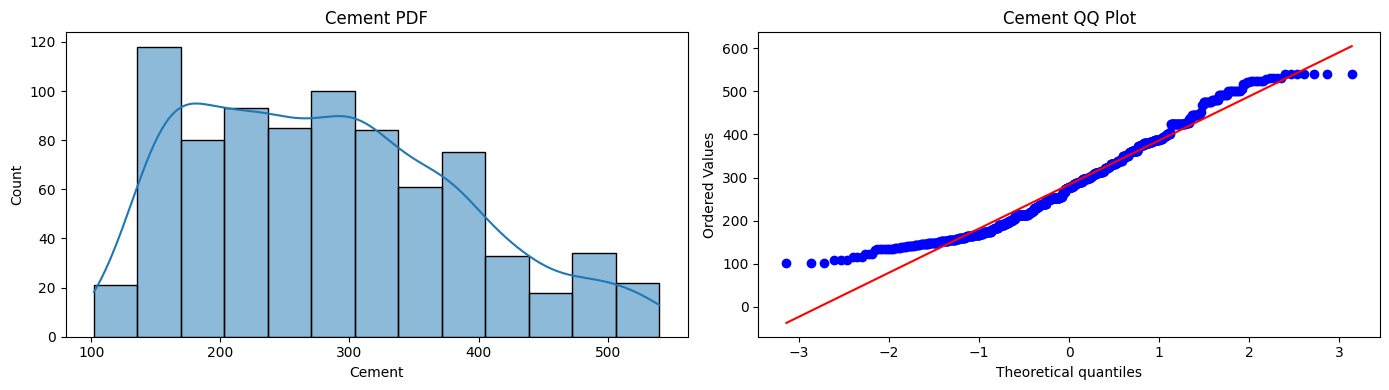

Skewness of Blast Furnace Slag : 0.8048928418904626


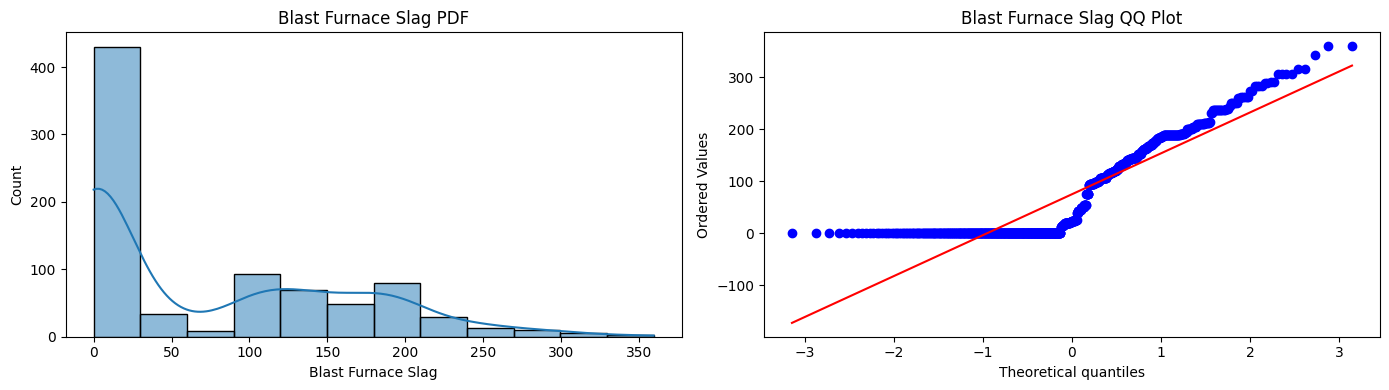

Skewness of Fly Ash : 0.5581669990165903


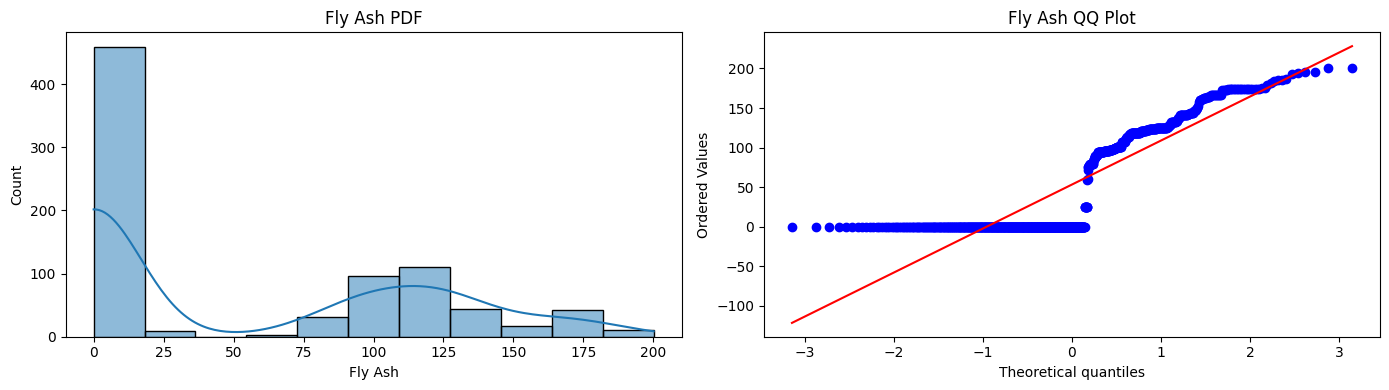

Skewness of Water : 0.09879259355284492


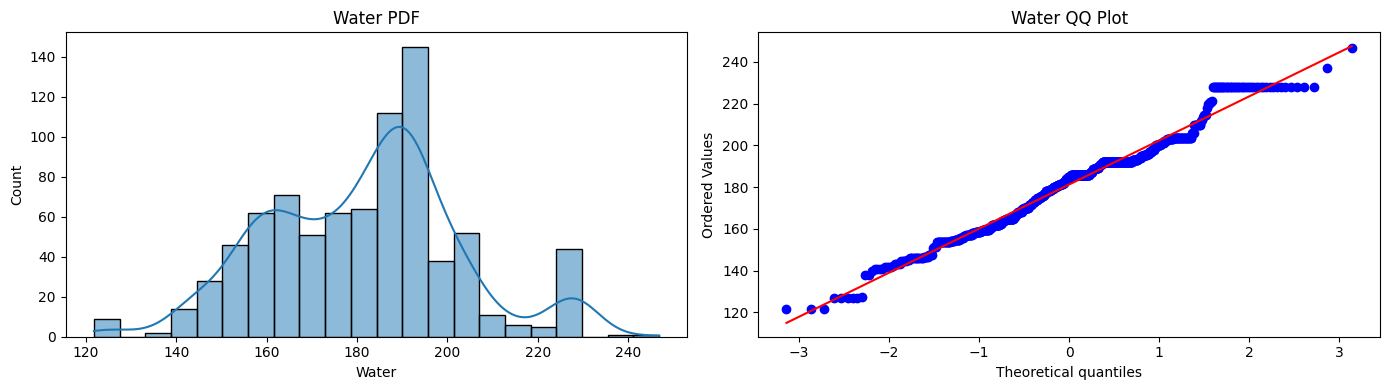

Skewness of Superplasticizer : 0.7873340899968494


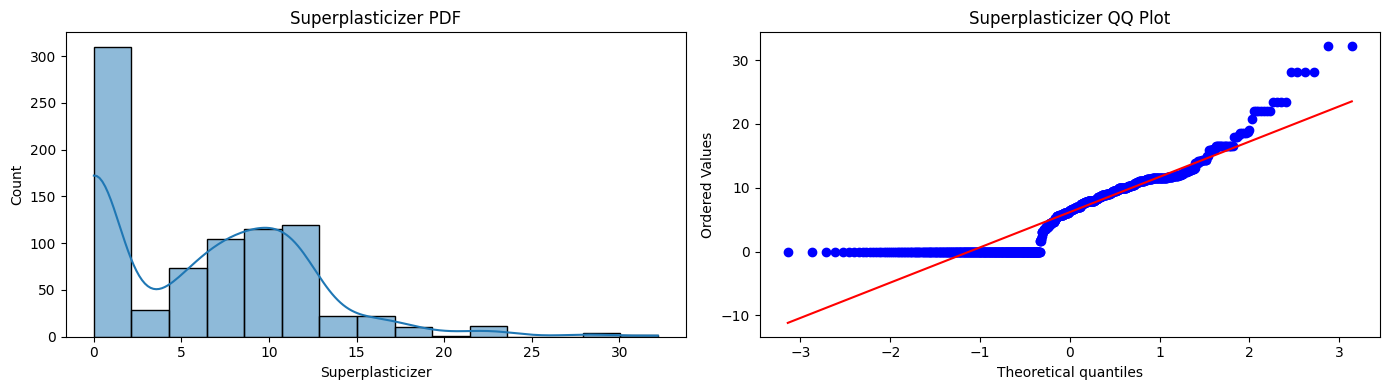

Skewness of Coarse Aggregate : -0.03703822679638557


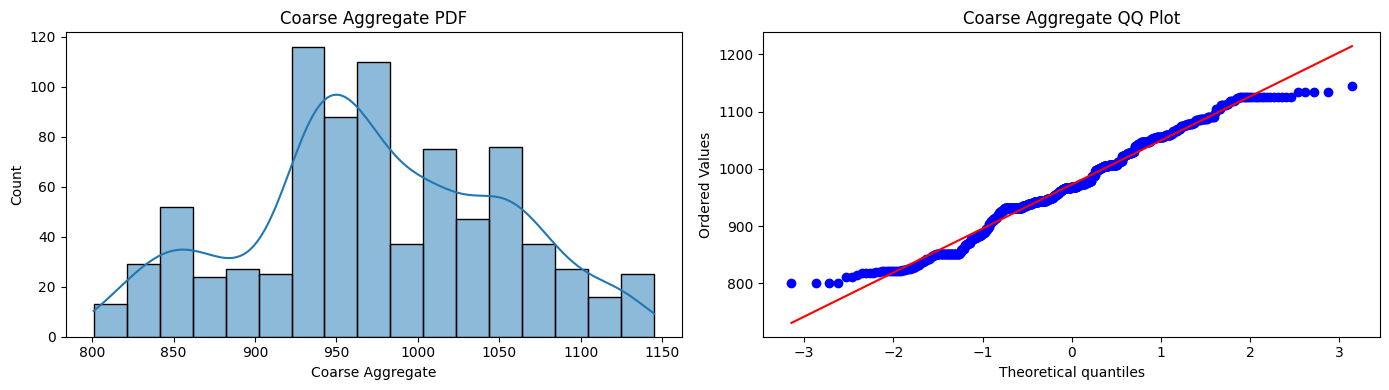

Skewness of Fine Aggregate : -0.27158211811332933


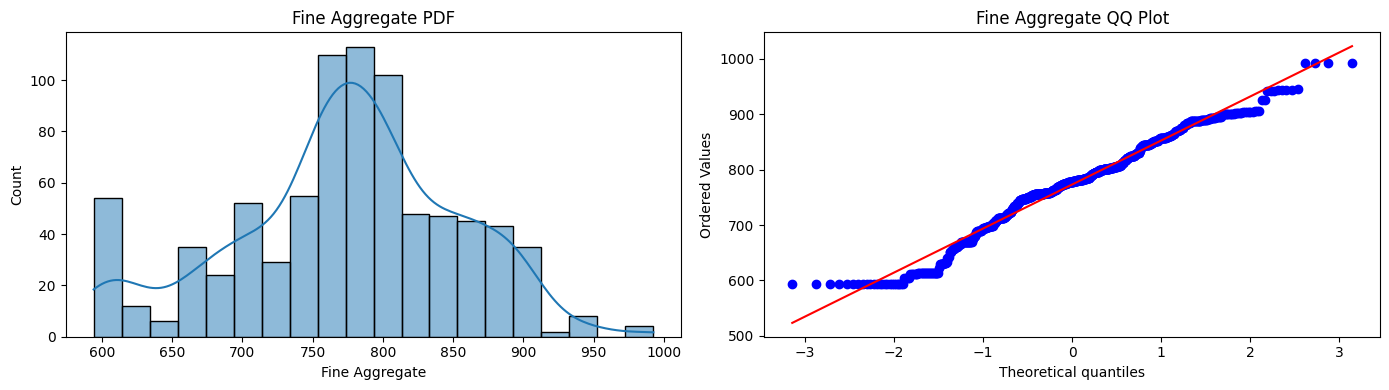

Skewness of Age : 3.3488335112714362


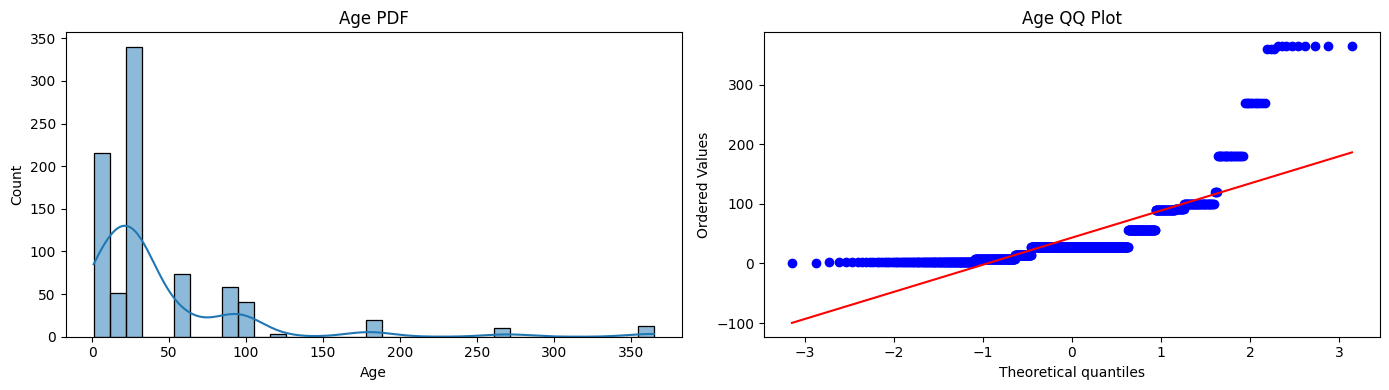

In [11]:
distplot_and_qqplot(X_train)

## 2. Power Transformation

In [12]:
# Function to apply Power Transformation on the dataset

def transform_data(X_train, X_test, apply_method):
    
    # Applying Power Transformation
    pt = PowerTransformer(method= apply_method, standardize=True)
    
    # Transforming the training and testing sets
    X_train_trans = pt.fit_transform(X_train+0.0000001) # Adding a small constant to avoid constants limitations in Power Transformation
    X_test_trans = pt.fit_transform(X_test+0.0000001)
    
    # Converting the transformed arrays back to DataFrames with original column names and indices
    X_train_trans = pd.DataFrame(
        X_train_trans,
        columns = X_train.columns,
        index = X_train.index
    )
    X_test_trans = pd.DataFrame(
            X_test_trans,
            columns = X_test.columns,
            index = X_test.index
        )

    # Calculating the best lambda values for each feature using the PowerTransformer object
    best_lambda = pd.DataFrame({
        'Features ' : X_train.columns,
        'lambda' : pt.lambdas_
    })
    
    
    return X_train_trans, X_test_trans, best_lambda



## 2.1 Box-Cox

In [13]:
# Applying Box-Cox Transformation on the dataset
X_train_trans, X_test_trans, best_lambda = transform_data(X_train, X_test, 'box-cox')

# Best lambda values for each feature after Box-Cox Transformation
best_lambda

,Features,lambda
0,Cement,0.008565
1,Blast Furnace Slag,0.004584
2,Fly Ash,-0.011493
3,Water,1.095783
4,Superplasticizer,0.094150
5,Coarse Aggregate,1.186103
6,Fine Aggregate,1.563306
7,Age,0.022978


### 2.1.1 Train Model

In [14]:
linear_model(X_train_trans, X_test_trans, y_train, y_test)

R2 Score : 0.7788386996574492
MAE      : 6.1857
RMSE     : 7.9403
Cross Validation Score: 0.7943


### 2.1.2 QQ Plots Before and After

Skewness of Cement Before : 0.4827336063794708 | Skewness of Cement After : -0.022648256953096767'


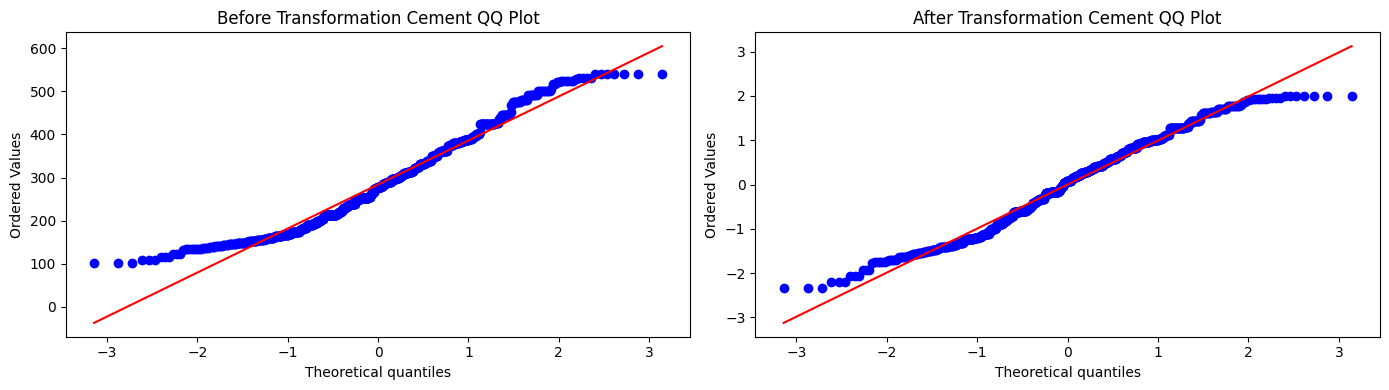

Skewness of Blast Furnace Slag Before : 0.8048928418904626 | Skewness of Blast Furnace Slag After : -0.1891542539088024'


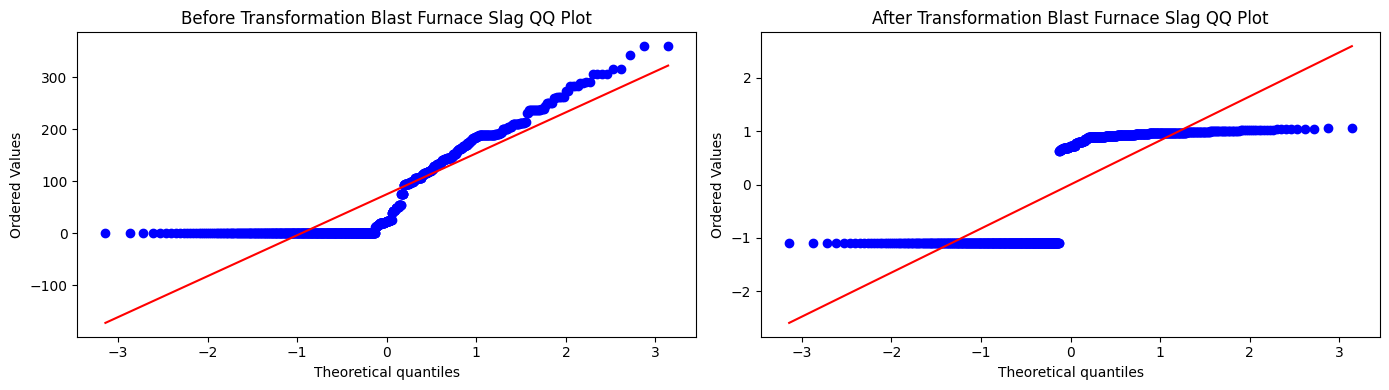

Skewness of Fly Ash Before : 0.5581669990165903 | Skewness of Fly Ash After : 0.2303480493456853'


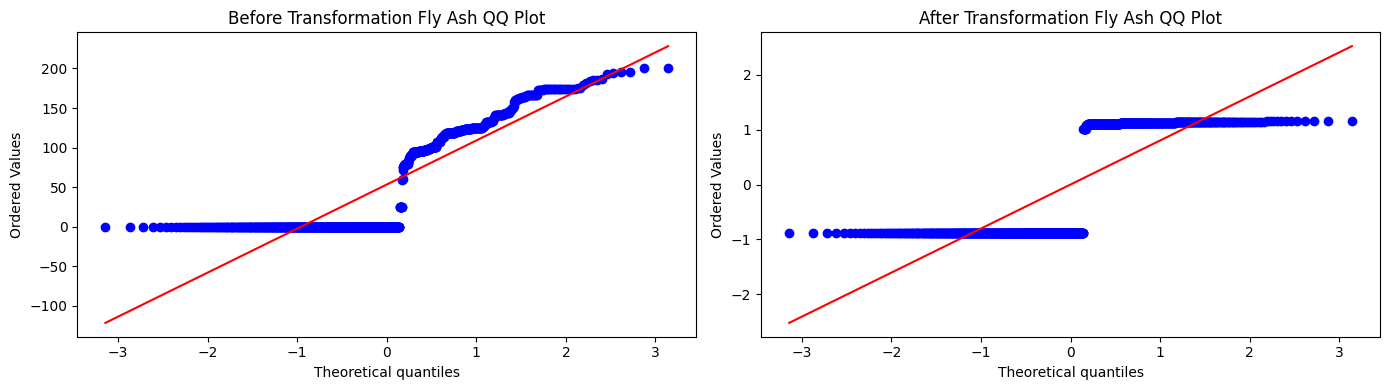

Skewness of Water Before : 0.09879259355284492 | Skewness of Water After : 0.0004849271954932809'


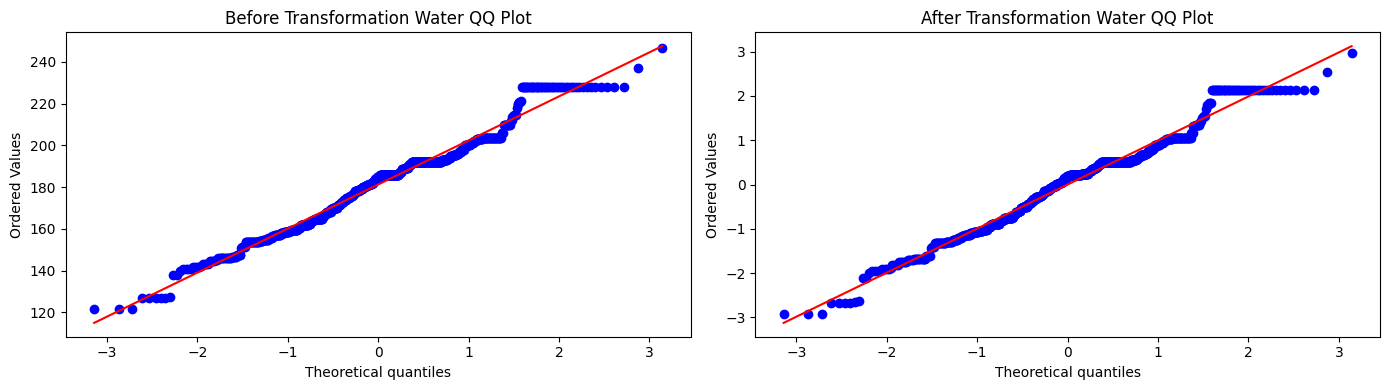

Skewness of Superplasticizer Before : 0.7873340899968494 | Skewness of Superplasticizer After : -0.5183519232944136'


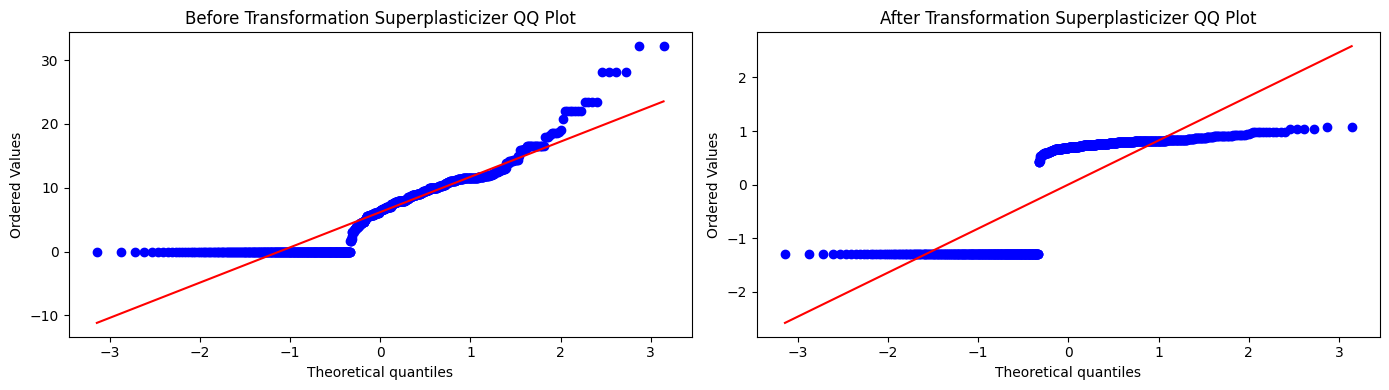

Skewness of Coarse Aggregate Before : -0.03703822679638557 | Skewness of Coarse Aggregate After : -0.017106234971037606'


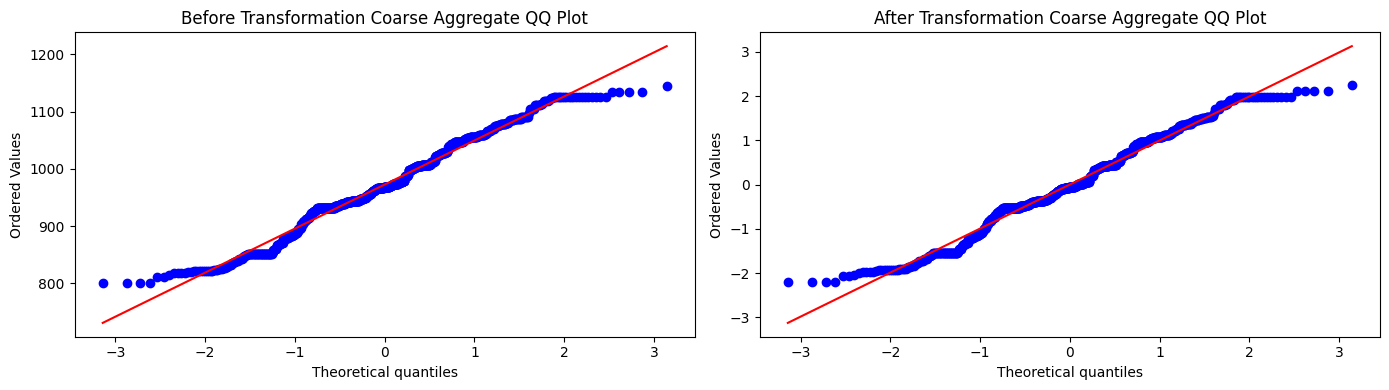

Skewness of Fine Aggregate Before : -0.27158211811332933 | Skewness of Fine Aggregate After : -0.015521667223917393'


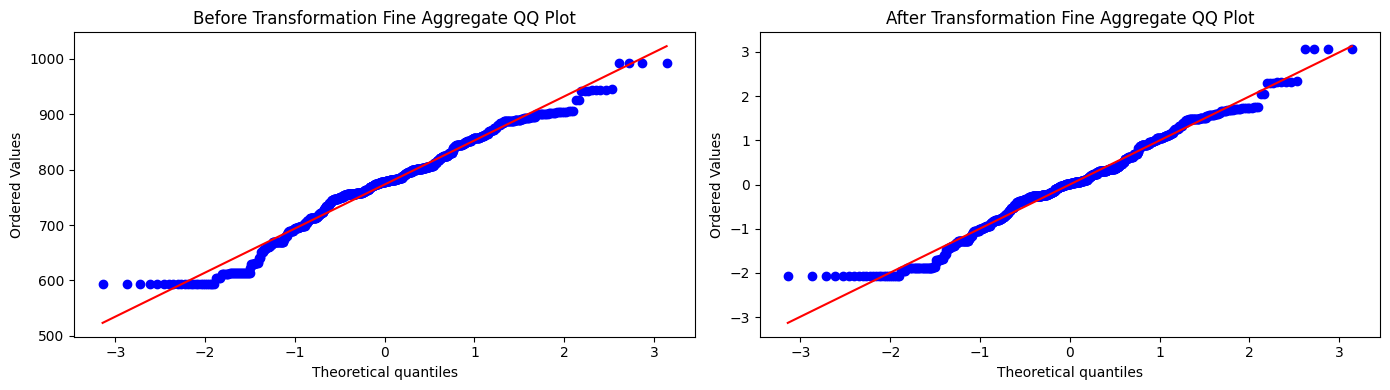

Skewness of Age Before : 3.3488335112714362 | Skewness of Age After : -0.007866978222232677'


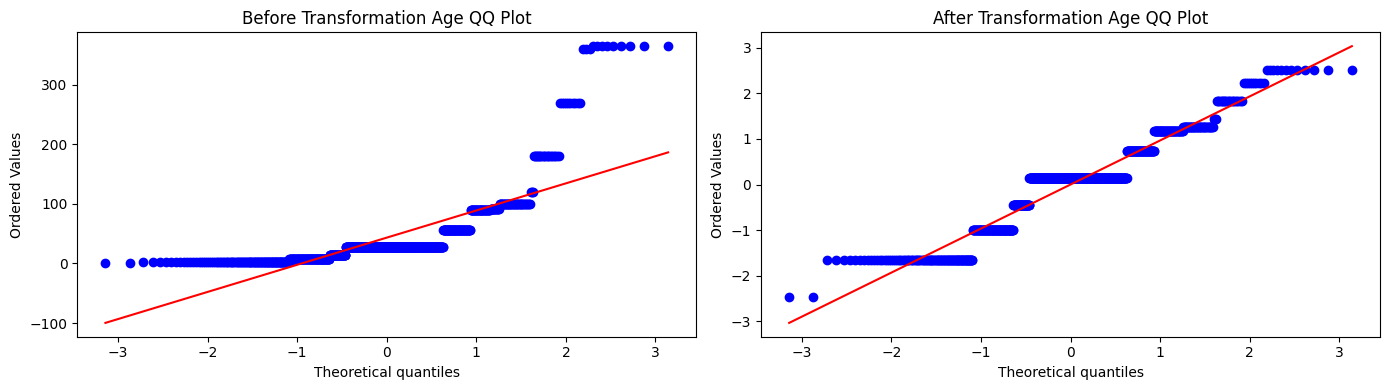

In [15]:
qq_plot(X_train, X_train_trans)

### 2.1.3 Distplot and QQ plots After Power Transformation

Skewness of Cement : -0.022648256953096767


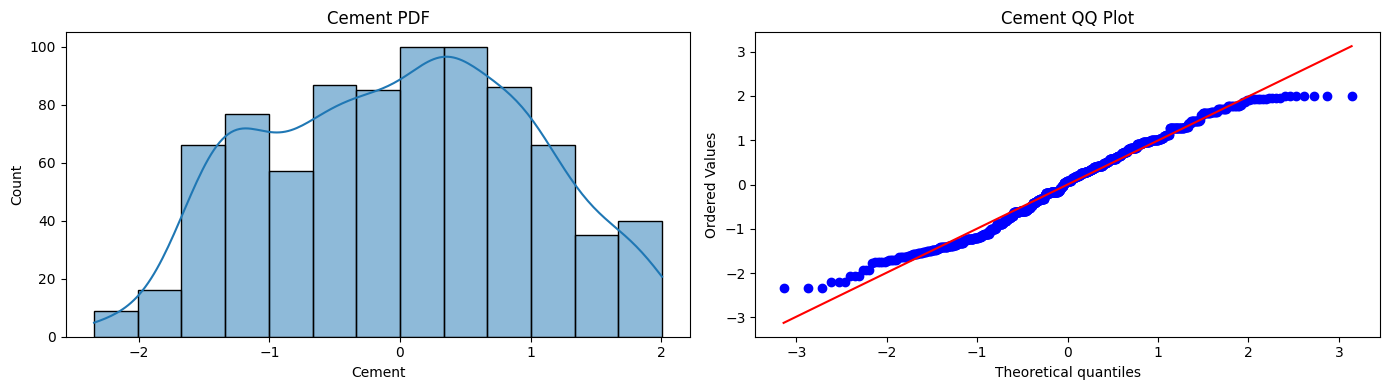

Skewness of Blast Furnace Slag : -0.1891542539088024


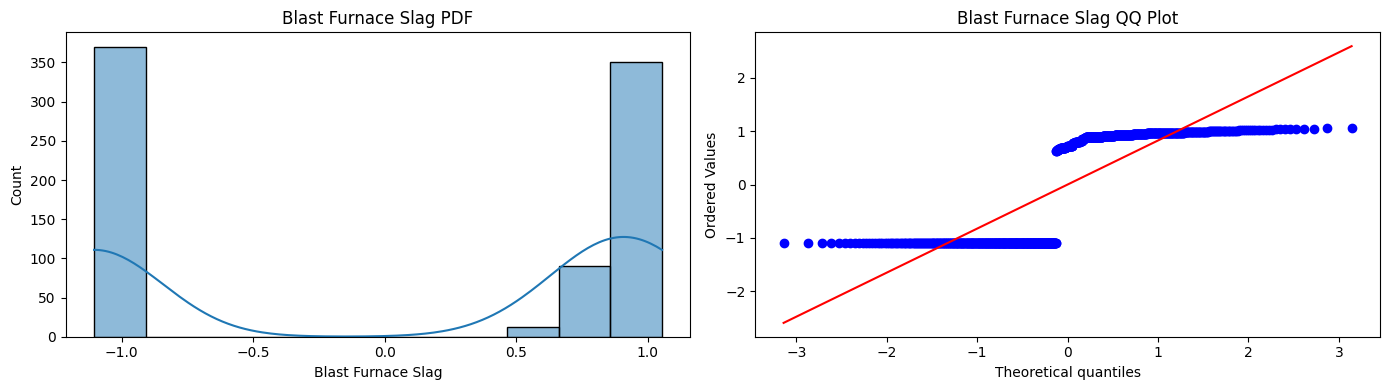

Skewness of Fly Ash : 0.2303480493456853


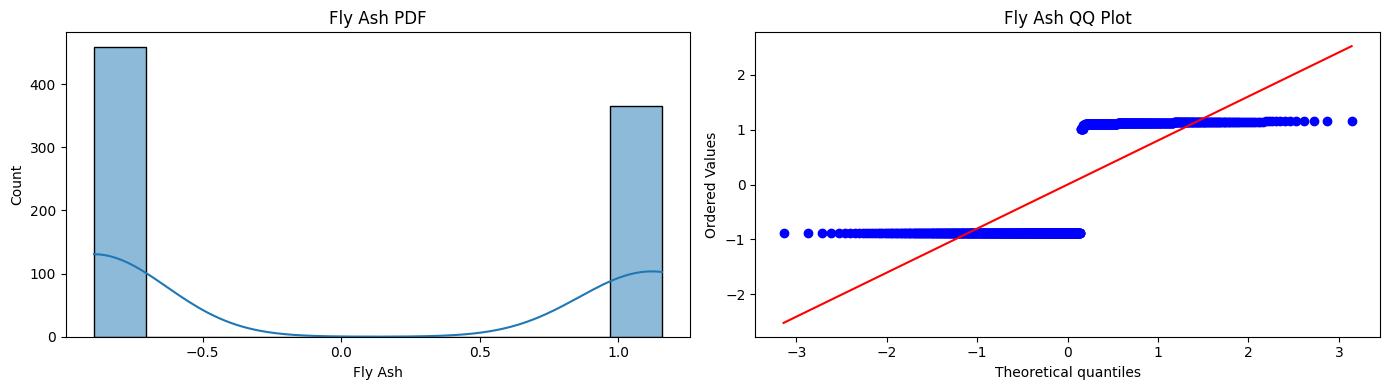

Skewness of Water : 0.0004849271954932809


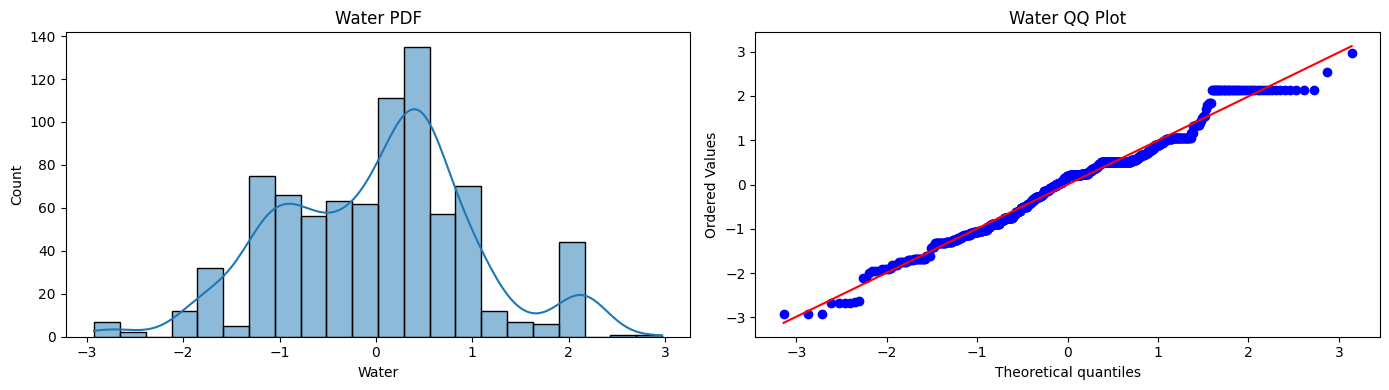

Skewness of Superplasticizer : -0.5183519232944136


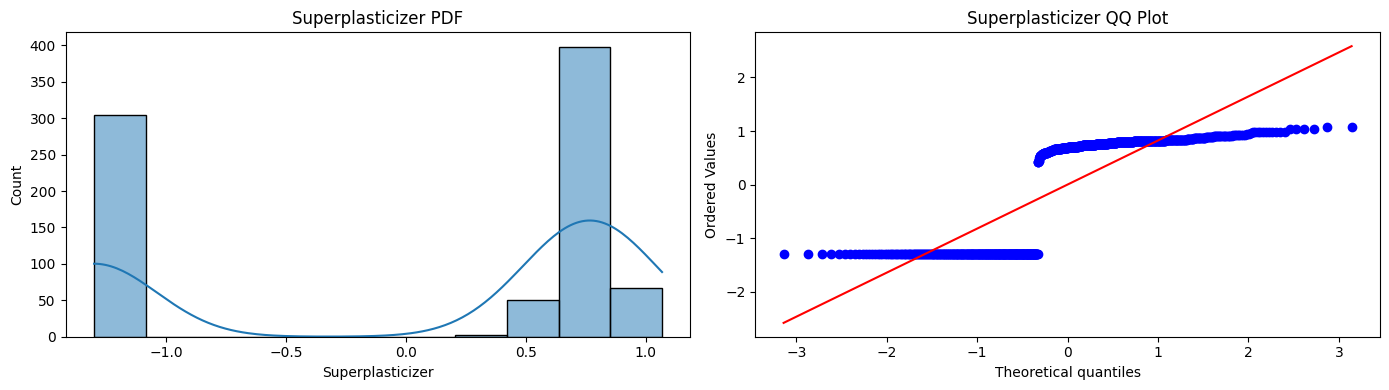

Skewness of Coarse Aggregate : -0.017106234971037606


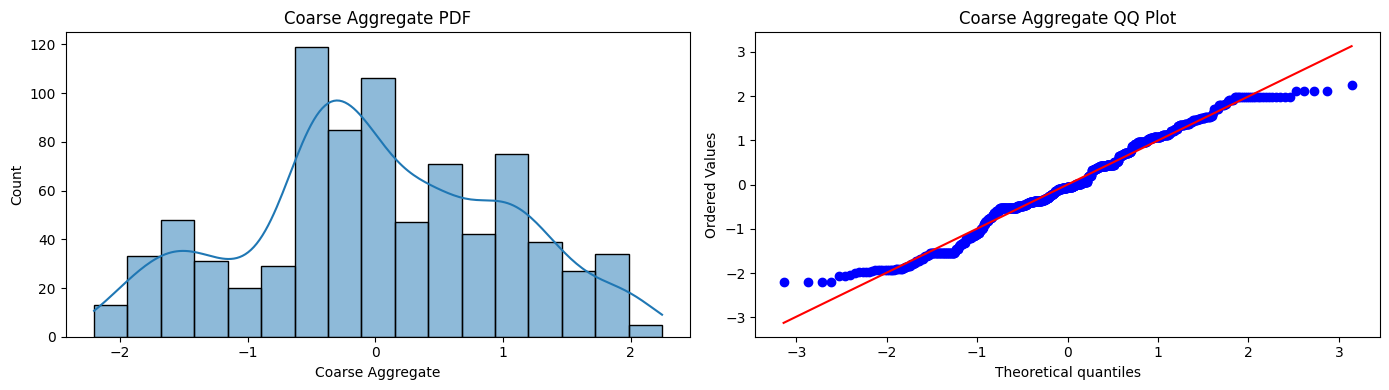

Skewness of Fine Aggregate : -0.015521667223917393


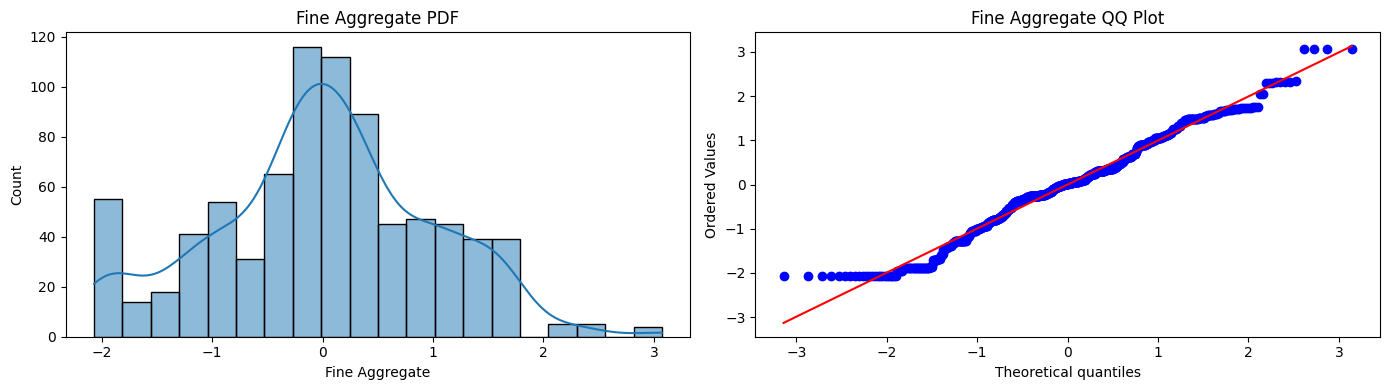

Skewness of Age : -0.007866978222232677


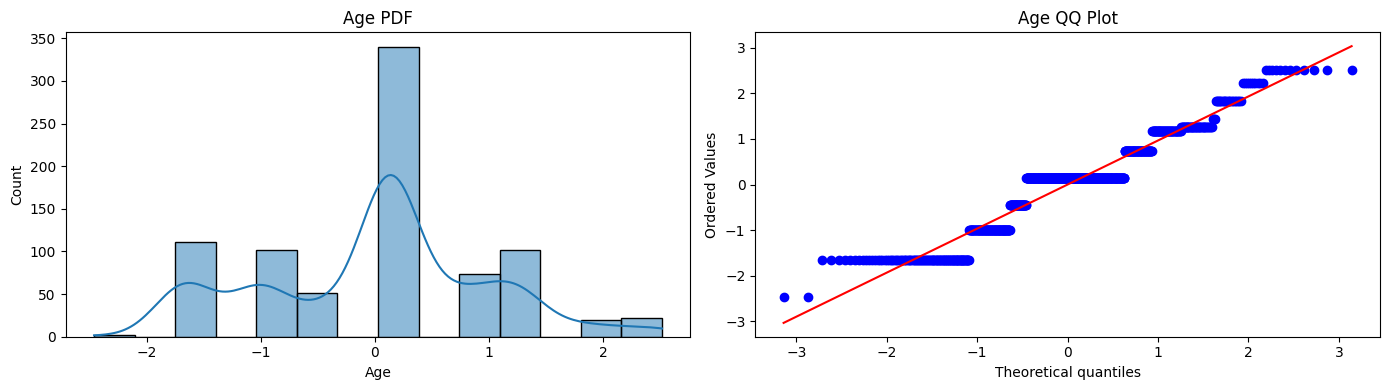

In [16]:
distplot_and_qqplot(X_train_trans)

## 3. Yeo-Johnson


In [17]:
# Applying Yeo-Johnson Transformation on the dataset
X_train_trans_yj, X_test_trans_yj, best_lambda_yj = transform_data(X_train, X_test, 'yeo-johnson')

# Best lambda values for each feature after Yeo-Johnson Transformation
best_lambda_yj

,Features,lambda
0,Cement,0.005143
1,Blast Furnace Slag,-0.032743
2,Fly Ash,-0.070253
3,Water,1.096120
4,Superplasticizer,0.257689
5,Coarse Aggregate,1.186418
6,Fine Aggregate,1.564066
7,Age,-0.021706


### 3.1 Train Model

In [18]:
linear_model(X_train_trans_yj, X_test_trans_yj, y_train, y_test)


R2 Score : 0.786140757000589
MAE      : 6.0087
RMSE     : 7.8082
Cross Validation Score: 0.7983


### 3.1.1 QQ Plots Before and After

Skewness of Cement Before : 0.4827336063794708 | Skewness of Cement After : -0.022287292267138735'


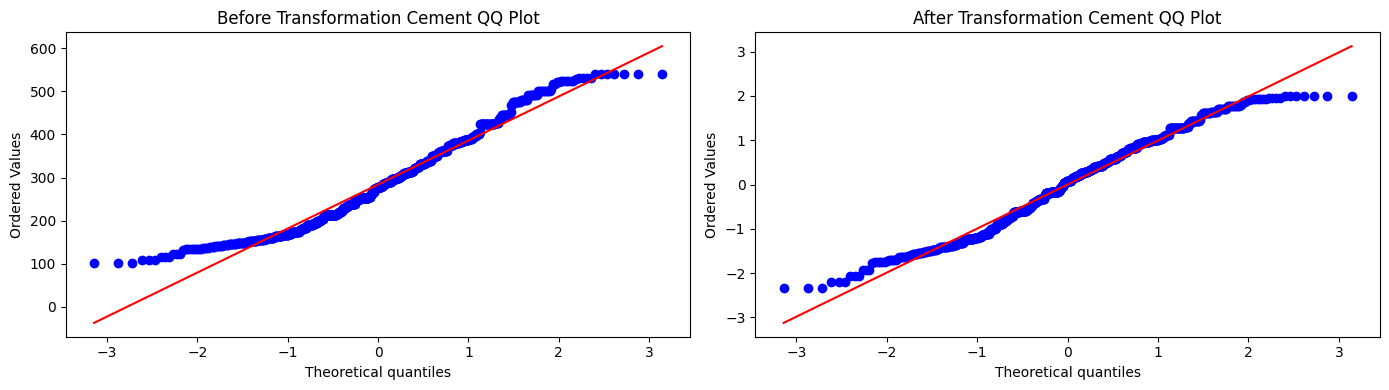

Skewness of Blast Furnace Slag Before : 0.8048928418904626 | Skewness of Blast Furnace Slag After : -0.04208199985767687'


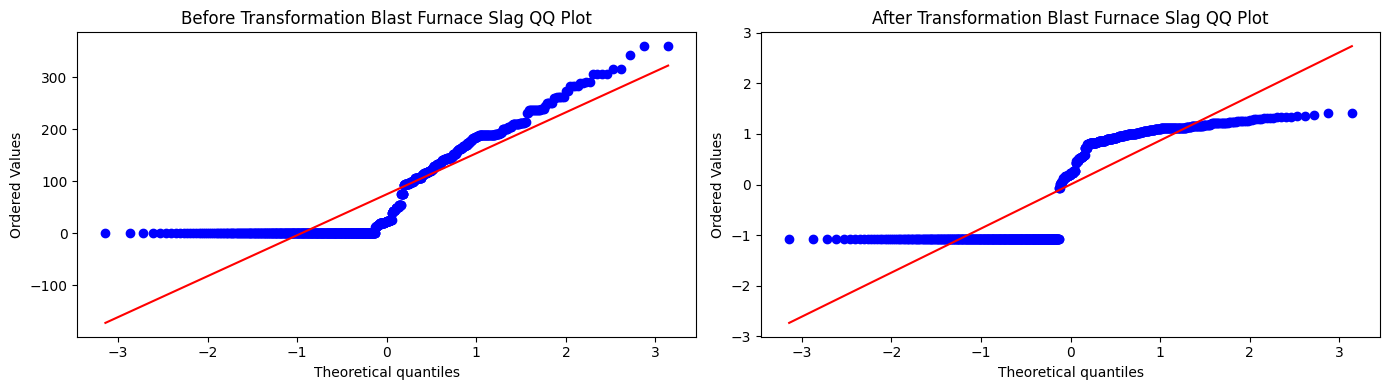

Skewness of Fly Ash Before : 0.5581669990165903 | Skewness of Fly Ash After : 0.2423071685534245'


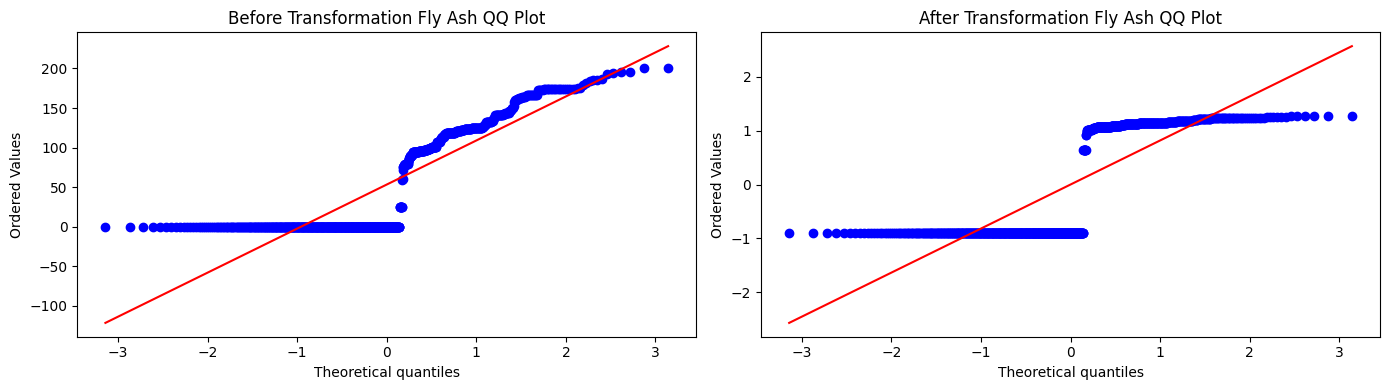

Skewness of Water Before : 0.09879259355284492 | Skewness of Water After : 0.0004806693983699572'


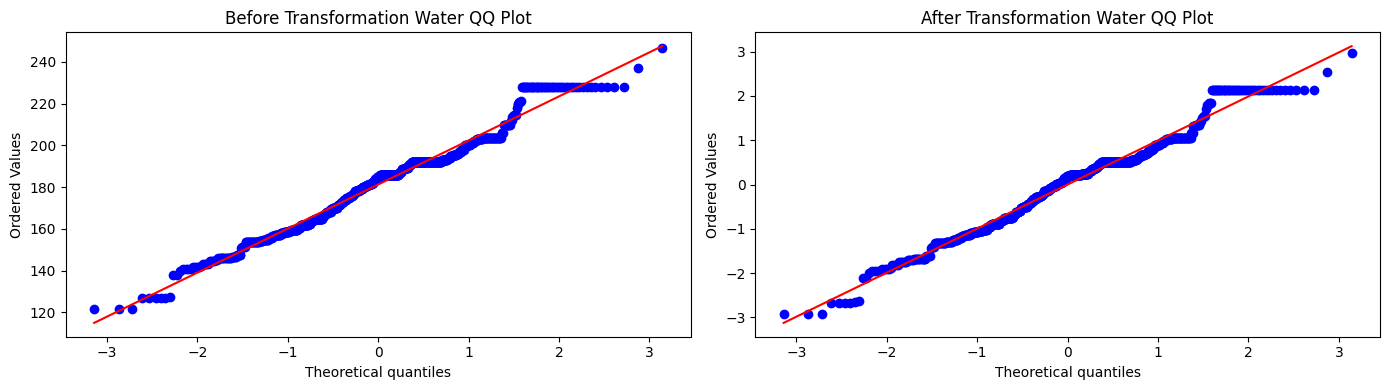

Skewness of Superplasticizer Before : 0.7873340899968494 | Skewness of Superplasticizer After : -0.16502311378533027'


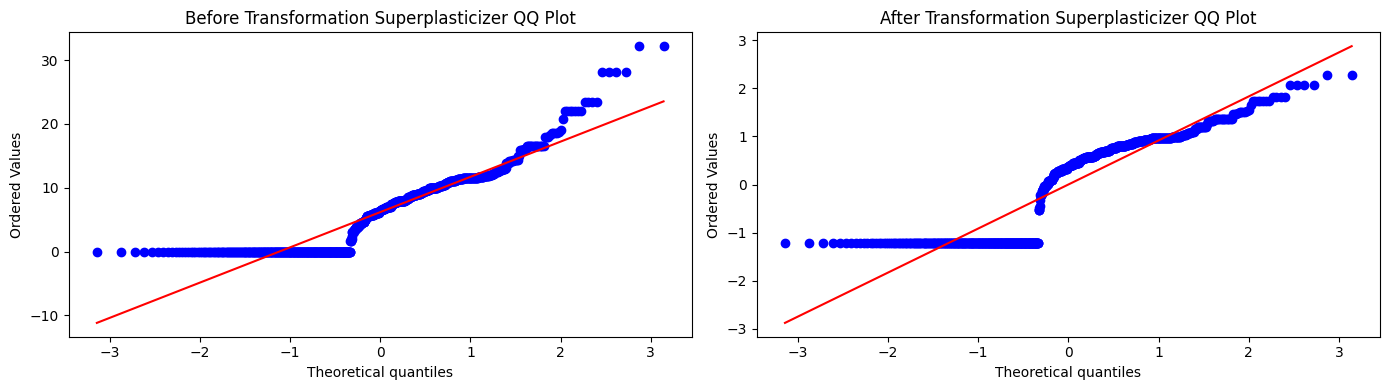

Skewness of Coarse Aggregate Before : -0.03703822679638557 | Skewness of Coarse Aggregate After : -0.01709148109637222'


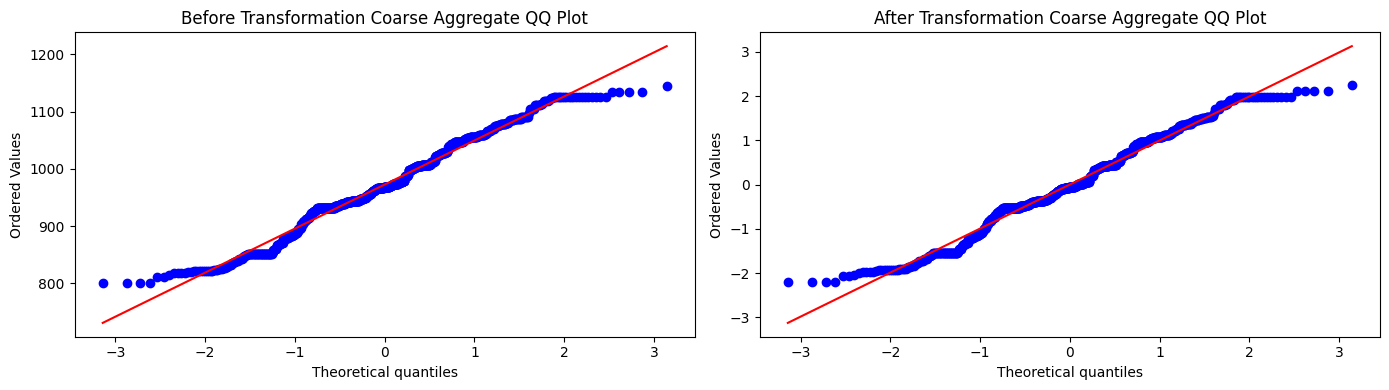

Skewness of Fine Aggregate Before : -0.27158211811332933 | Skewness of Fine Aggregate After : -0.015503842068072211'


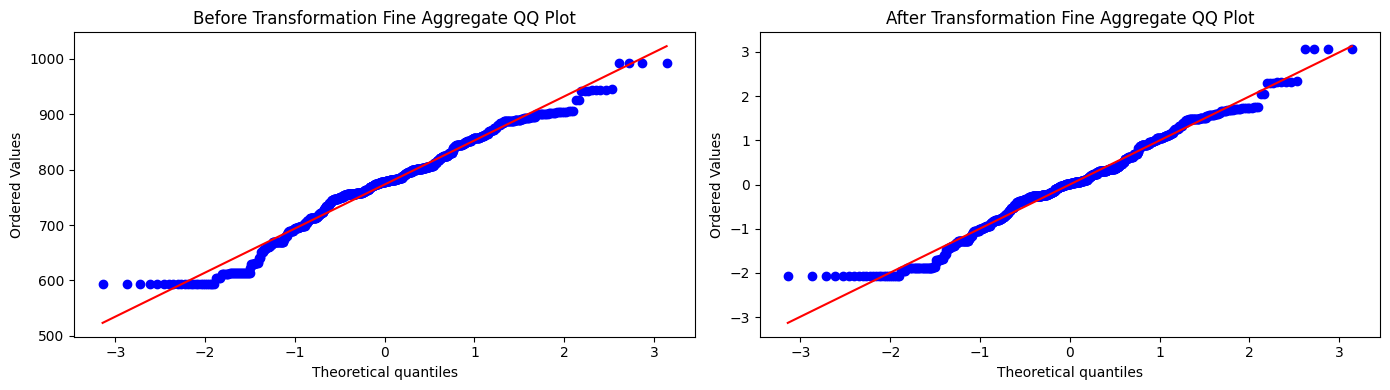

Skewness of Age Before : 3.3488335112714362 | Skewness of Age After : -0.0016222685549292046'


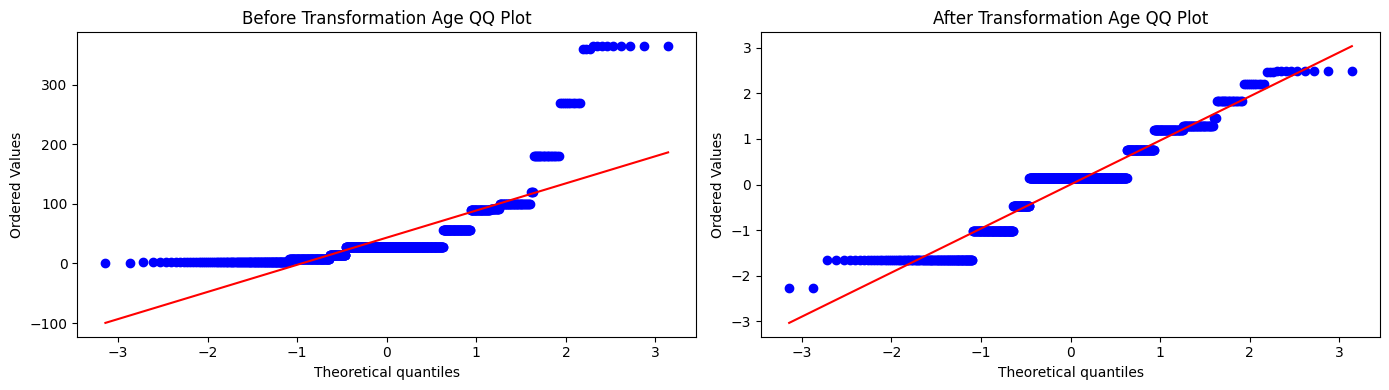

In [19]:
qq_plot(X_train, X_train_trans_yj)

## Summary !!

In [20]:
# Calculating skewness for original and transformed datasets

skew_data = skew(X_train).ravel() ## Skewness of original data
skew_trans = skew(X_train_trans).ravel() ## Skewness of Box-Cox transformed data
skew_trans_yj = skew(X_train_trans_yj).ravel() ## Skewness of Yeo-Johnson transformed data

# Comparing the best lambda values and skewness for each feature after Box-Cox and Yeo-Johnson transformations
compare_lambda = pd.DataFrame({
        'Features ' : X_train.columns,
        'lambda box-cox' : best_lambda['lambda'],
        'lambda yeo-johnson' : best_lambda_yj['lambda'], 
        'skewness(data)': skew_data,
        'skewness(trans)': skew_trans,
        'skewness(trans-yj)': skew_trans_yj
    })

compare_lambda

,Features,lambda box-cox,lambda yeo-johnson,skewness(data),skewness(trans),skewness(trans-yj)
0,Cement,0.008565,0.005143,0.482734,-0.022648,-0.022287
1,Blast Furnace Slag,0.004584,-0.032743,0.804893,-0.189154,-0.042082
2,Fly Ash,-0.011493,-0.070253,0.558167,0.230348,0.242307
3,Water,1.095783,1.096120,0.098793,0.000485,0.000481
4,Superplasticizer,0.094150,0.257689,0.787334,-0.518352,-0.165023
5,Coarse Aggregate,1.186103,1.186418,-0.037038,-0.017106,-0.017091
6,Fine Aggregate,1.563306,1.564066,-0.271582,-0.015522,-0.015504
7,Age,0.022978,-0.021706,3.348834,-0.007867,-0.001622


## Structural Necessity: Why and When to Choose PowerTransformer?

While manual math functions are simple, `PowerTransformer` is a critical requirement in robust, automated machine learning workflows for three major reasons:

#### 1. Automation of Feature Engineering

Manual transformations require manual intervention and can lead to errors or inconsistencies. For instance, if we manually apply a log transformation to manually inspect every single feature via plots, calculate individual skew numbers, and hardcode distinct numpy operations feature-by-feature. `PowerTransformer` evaluates hundreds of features simultaneously, optimizing a unique $\lambda$ tailored to the exact skewness profile of each feature automatically.

#### 2. Optimization Beyond Basic Math Boundaries

Data skewness is rarely a perfect log curve or a perfect square root curve; it often sits somewhere in between. For example, a feature might look best under a power of $\lambda = 0.234$. A manual `FunctionTransformer` cannot guess this arbitrary exponent, whereas `PowerTransformer` identifies it via numerical optimization.

#### 3. Preserving Generalization without Data Leakage

In machine learning pipelines, we must never calculate statistics using the test set. If we manually tweak scaling parameters based on the whole dataset, we leak the data. Because `PowerTransformer` stores its discovered $\lambda\$ parameter inside the object during `.fit(X_train)`, we can safely apply `.transform(X_test)` later, ensuring the test set is handled exactly like the training set without breaking validation integrity.

---


## Applied Use Cases: Where PowerTransformer Drives Performance

`PowerTransformer` yields massive performance gains when paired with parametric, linear, or distance-based estimators.

#### 1. Linear and Logistic Regression Models

Linear estimators require homoscedasticity (errors having constant variance). When our dataset features target continuous variables with severe heteroscedasticity, fitting a raw regression model leads to highly unstable, high-variance coefficient estimates. `PowerTransformer` smooths out variance disparities, generating narrow, dependable confidence intervals for weights.

#### 2. K-Nearest Neighbors (KNN) and Support Vector Machines (SVM)

Distance-based algorithms calculate spatial metrics (like Euclidean distance) between points. If a single feature has an aggressively skewed distribution with extreme right-side scales, it disproportionately warping the distance matrix. Transforming these features flattens spatial clusters, enabling balanced distance calculations across all dimensions.

#### 3. Principle Component Analysis (PCA) for Dimensionality Reduction

PCA acts by finding orthogonal axes that maximize feature variance. If data features are highly skewed, the primary components will blindly align along the outlier tails rather than mapping the structural variations of the majority class. Transforming data prior to running PCA yields cleaner, more meaningful low-dimensional representations.

#### 4. Tree-Based Models Exception Reminder

Just like manual function transformations, `PowerTransformer` provides **zero value** for decision tree variants (Random Forest, XGBoost, CatBoost). Decision trees evaluate ordinal partitions ($X \leq \text{threshold}$) and are invariant to monotonic scaling adjustments. Skip this preprocessing step if your final estimator is ensemble tree-based.
